In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

## **Первичный анализ для 1 датасета**

In [93]:
df1 = pd.read_csv("data/S07-hw-dataset-01.csv")
sample_id_1 = df1["sample_id"].copy()
X1 = df1.drop(columns=["sample_id"])
display(df1.head())
df1.info()
display(X1.describe())
print(df1.isnull().sum())
print("\nДоля пропусков:")
print(df1.isnull().mean())
numeric_cols_1 = X1.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_1 = X1.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nЧисловые признаки:", numeric_cols_1)
print("Категориальные признаки:", categorical_cols_1 if categorical_cols_1 else "отсутствуют")
df1.shape

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64

Доля пропусков:
sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64

Числовые признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Категориальные признаки: отсутствуют


(12000, 9)

## **Первичный анализ для 2 датасета**

In [96]:
df2 = pd.read_csv("data/S07-hw-dataset-02.csv")
sample_id_2 = df2["sample_id"].copy()
X2 = df2.drop(columns=["sample_id"])
display(df2.head())
df2.info()
display(X2.describe())
print("\nКоличество пропусков по столбцам:")
print(df2.isnull().sum())
print("\nДоля пропусков:")
print(df2.isnull().mean())
numeric_cols_2 = X2.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_2 = X2.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nЧисловые признаки:", numeric_cols_2)
print("Категориальные признаки:", categorical_cols_2 if categorical_cols_2 else "отсутствуют")

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


,x1,x2,z_noise
count,8000.000000,8000.000000,8000.000000
mean,0.478867,0.241112,0.110454
std,0.955138,0.663195,8.097716
min,-2.487352,-2.499237,-34.056074
25%,-0.116516,-0.242357,-5.392210
50%,0.490658,0.241092,0.132470
75%,1.085263,0.726526,5.655605
max,2.987555,2.995553,29.460076



Количество пропусков по столбцам:
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

Доля пропусков:
sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64

Числовые признаки: ['x1', 'x2', 'z_noise']
Категориальные признаки: отсутствуют


## **Первичный анализ для 3 датасета**

In [99]:
df3 = pd.read_csv("data/S07-hw-dataset-03.csv")
sample_id_3 = df3["sample_id"].copy()
X3 = df3.drop(columns=["sample_id"])
display(df3.head())
df3.info()
display(X3.describe())
print("\nКоличество пропусков по столбцам:")
print(df3.isnull().sum())
print("\nДоля пропусков:")
print(df3.isnull().mean())
numeric_cols_3 = X3.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_3 = X3.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nЧисловые признаки:", numeric_cols_3)
print("Категориальные признаки:", categorical_cols_3 if categorical_cols_3 else "отсутствуют")

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.246296,1.033764,0.212776,-0.027067
std,4.592421,4.710791,1.530017,2.506375
min,-9.995585,-9.980853,-5.212038,-8.785884
25%,-1.782144,-2.666393,-0.966224,-1.731128
50%,0.664226,1.831257,0.296508,-0.052391
75%,4.435671,4.969630,1.390273,1.673831
max,16.207863,14.271153,5.795876,11.266865



Количество пропусков по столбцам:
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64

Доля пропусков:
sample_id    0.0
x1           0.0
x2           0.0
f_corr       0.0
f_noise      0.0
dtype: float64

Числовые признаки: ['x1', 'x2', 'f_corr', 'f_noise']
Категориальные признаки: отсутствуют


## **Препроцессинг**

In [102]:
prep_pipe_1 = Pipeline([
    ('scaler', StandardScaler())
])
X1_scaled = prep_pipe_1.fit_transform(X1)
print("датасет 1: препроцессинг, форма:", X1_scaled.shape)

prep_pipe_2 = Pipeline([
    ('scaler', StandardScaler())
])
X2_scaled = prep_pipe_2.fit_transform(X2)
print("датасет 2: препроцессинг, форма:", X2_scaled.shape)

prep_pipe_3 = Pipeline([
    ('scaler', StandardScaler())
])
X3_scaled = prep_pipe_3.fit_transform(X3)
print("датасет 3: препроцессинг, форма:", X3_scaled.shape)

датасет 1: препроцессинг, форма: (12000, 8)
датасет 2: препроцессинг, форма: (8000, 3)
датасет 3: препроцессинг, форма: (15000, 4)


## **Датасет 1**

In [203]:
k_range = range(2, 21)
RANDOM_STATE = 15
kmeans_results_1 = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    sil = silhouette_score(X1_scaled, labels)
    db = davies_bouldin_score(X1_scaled, labels)
    ch = calinski_harabasz_score(X1_scaled, labels)
    
    kmeans_results_1.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'labels': labels.copy()
    })

best_kmeans_1 = max(kmeans_results_1, key=lambda x: x['silhouette'])
print(f"\nKMeans: лучший k = {best_kmeans_1['k']}")
print(f"Silhouette: {best_kmeans_1['silhouette']:.4f}")
print(f"Davies-Bouldin: {best_kmeans_1['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz: {best_kmeans_1['calinski_harabasz']:.2f}")


KMeans: лучший k = 2
Silhouette: 0.5216
Davies-Bouldin: 0.6853
Calinski-Harabasz: 11786.95


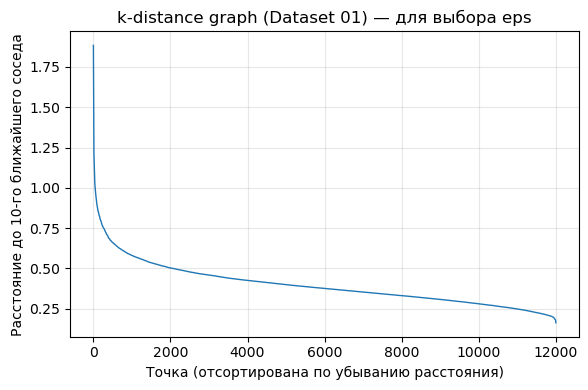


DBSCAN Dataset 01

DBSCAN: лучшие параметры: eps=2.0, min_samples=5
Кластеров: 2, шум: 0.00%
Silhouette (non-noise): 0.5216
Davies-Bouldin: 0.6853
Calinski-Harabasz: 11786.95


In [204]:
min_samples_vals = [5, 10, 15, 20]
knn = NearestNeighbors(n_neighbors=10) 
knn.fit(X1_scaled) 
distances, _ = knn.kneighbors(X1_scaled)
k_distances = np.sort(distances[:, -1])[::-1] 

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=1)
plt.title('k-distance graph (Dataset 01) — для выбора eps')
plt.xlabel('Точка (отсортирована по убыванию расстояния)')
plt.ylabel('Расстояние до 10-го ближайшего соседа')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dbscan_eps_ds1.png')
plt.show()

eps_candidates = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
dbscan_results_1 = []
print("\nDBSCAN Dataset 01")
for min_samples in min_samples_vals:
    for eps in eps_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_scaled)
        n_noise = np.sum(labels == -1)
        noise_ratio = n_noise / len(labels)
        non_noise_mask = labels != -1
        unique_labels = np.unique(labels[non_noise_mask])
        if np.sum(non_noise_mask) < 2 or len(unique_labels) < 2:
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            sil = silhouette_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
        dbscan_results_1.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch,
            'labels': labels.copy()
        })

valid_dbscan = [r for r in dbscan_results_1 if not np.isnan(r['silhouette'])]
if valid_dbscan:
    best_dbscan_1 = max(valid_dbscan, key=lambda x: x['silhouette'])
    print(f"\nDBSCAN: лучшие параметры: eps={best_dbscan_1['eps']}, min_samples={best_dbscan_1['min_samples']}")
    print(f"Кластеров: {best_dbscan_1['n_clusters']}, шум: {best_dbscan_1['noise_ratio']:.2%}")
    print(f"Silhouette (non-noise): {best_dbscan_1['silhouette']:.4f}")
    print(f"Davies-Bouldin: {best_dbscan_1['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz: {best_dbscan_1['calinski_harabasz']:.2f}")
else:
    best_dbscan_1 = None
    print("\nНет валидных DBSCAN-моделей (слишком много шума).")

In [205]:
print("Сравнение моделей на первом датасете")

print("\nKMeans (лучший):") # лучшее количество кластеров
print(f"  k = {best_kmeans_1['k']}")
print(f"  Silhouette: {best_kmeans_1['silhouette']:.4f}")

if best_dbscan_1: # если dbscan удалось настроить
    print("\nDBSCAN (лучший):")
    print(f"  eps = {best_dbscan_1['eps']}, min_samples = {best_dbscan_1['min_samples']}")
    print(f"  Шум: {best_dbscan_1['noise_ratio']:.2%}")
    print(f"  Silhouette (non-noise): {best_dbscan_1['silhouette']:.4f}")
else:
    print("\nDBSCAN: не удалось получить валидную модель.")

if best_dbscan_1 and best_dbscan_1['silhouette'] > best_kmeans_1['silhouette']:
    best_model_1 = 'dbscan'
    best_labels_1 = best_dbscan_1['labels']
    print("\n DBSCAN - лучшая модель.")
else:
    best_model_1 = 'kmeans'
    best_labels_1 = best_kmeans_1['labels']
    print("\n KMeans - лучшая модель.")

Сравнение моделей на первом датасете

KMeans (лучший):
  k = 2
  Silhouette: 0.5216

DBSCAN (лучший):
  eps = 2.0, min_samples = 5
  Шум: 0.00%
  Silhouette (non-noise): 0.5216

 KMeans - лучшая модель.


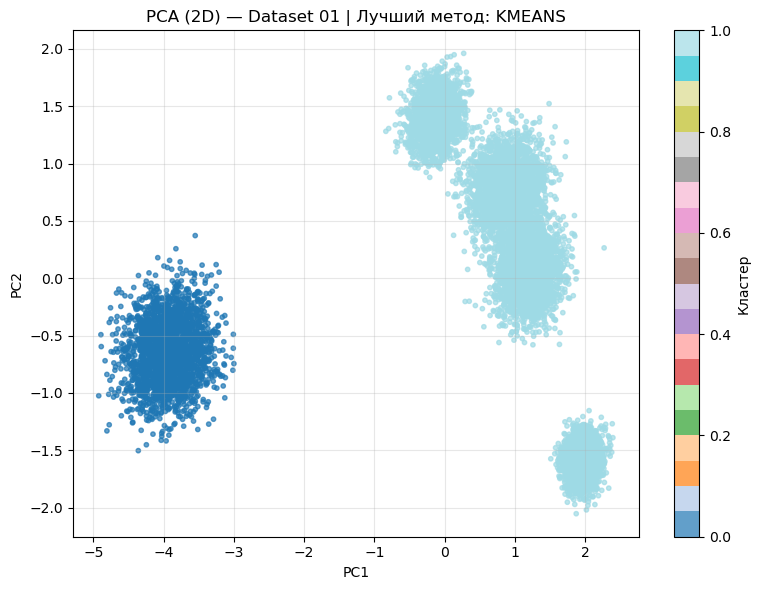


 Артефакты сохранены:
 - artifacts/figures/pca_ds1.png
 - artifacts/figures/dbscan_eps_ds1.png
 - artifacts/labels/labels_hw07_ds1.csv


In [206]:
pca = PCA(n_components=2, random_state=15)
X1_pca = pca.fit_transform(X1_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=best_labels_1, cmap='tab20', s=10, alpha=0.7)
plt.colorbar(scatter, label='Кластер')
plt.title(f'PCA (2D) — Dataset 01 | Лучший метод: {best_model_1.upper()}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/pca_ds1.png') 
plt.show()
labels_df_1 = pd.DataFrame({
    'sample_id': sample_id_1,
    'cluster_label': best_labels_1
})
labels_df_1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)  
print("\n Артефакты сохранены:")
print(" - artifacts/figures/pca_ds1.png")
print(" - artifacts/figures/dbscan_eps_ds1.png")
print(" - artifacts/labels/labels_hw07_ds1.csv")

In [207]:
print("Проверка устойчивости для 1 датасета (KMeans)")

k_stable = best_kmeans_1['k']
ari_scores = []
for seed in range(5):
    km1 = KMeans(n_clusters=k_stable, random_state=seed, n_init=10)
    km2 = KMeans(n_clusters=k_stable, random_state=seed + 100, n_init=10)
    labels1 = km1.fit_predict(X1_scaled)
    labels2 = km2.fit_predict(X1_scaled)
    ari = adjusted_rand_score(labels1, labels2)
    ari_scores.append(ari)
    print(f"Сравнение запусков {seed} и {seed+100}: ARI = {ari:.4f}")

print(f"\nСредний ARI между разными запусками: {np.mean(ari_scores):.4f}")

Проверка устойчивости для 1 датасета (KMeans)
Сравнение запусков 0 и 100: ARI = 1.0000
Сравнение запусков 1 и 101: ARI = 1.0000
Сравнение запусков 2 и 102: ARI = 1.0000
Сравнение запусков 3 и 103: ARI = 1.0000
Сравнение запусков 4 и 104: ARI = 1.0000

Средний ARI между разными запусками: 1.0000


#### **Итог датасет 1**

Оба алгоритма показали идентичное качество (Silhouette=0.5216) и выделили 2 кластера. DBSCAN не обнаружил шума, что указывает на четкую структуру данных. KMeans демонстрирует идеальную устойчивость (ARI=1.0).

Выбор пал на KMeans, несмотря на равные метрики, по нескольким причинам: алгоритм проще интерпретировать благодаря центроидам, он быстрее работает и легче настраивается. Поскольку данные не содержат шума и, вероятно, имеют выпуклую форму кластеров, дополнительные возможности DBSCAN по работе с аномалиями не востребованы. KMeans обеспечивает воспроизводимость и достаточную эффективность для данной задачи.

## **Датасет 2**

KMeans на датасете 02


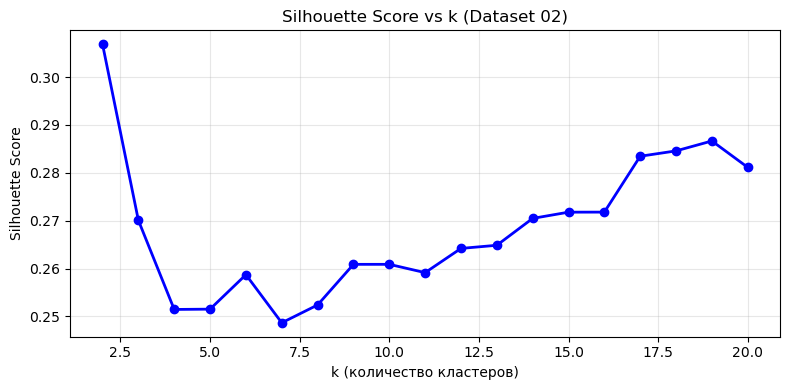


KMeans: лучший k = 2
Silhouette: 0.3069
Davies-Bouldin: 1.3235
Calinski-Harabasz: 3573.39


In [190]:
k_range = range(2, 21)
RANDOM_STATE = 15
kmeans_results_2 = []

print("KMeans на датасете 02")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    sil = silhouette_score(X2_scaled, labels)
    db = davies_bouldin_score(X2_scaled, labels)
    ch = calinski_harabasz_score(X2_scaled, labels)
    kmeans_results_2.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'labels': labels.copy()
    })

best_kmeans_2 = max(kmeans_results_2, key=lambda x: x['silhouette'])

plt.figure(figsize=(8, 4))
plt.plot(k_range, [r['silhouette'] for r in kmeans_results_2], 'bo-', linewidth=2, markersize=6)
plt.title('Silhouette Score vs k (Dataset 02)')
plt.xlabel('k (количество кластеров)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/silhouette_kmeans_ds2.png') 
plt.show()
print(f"\nKMeans: лучший k = {best_kmeans_2['k']}")
print(f"Silhouette: {best_kmeans_2['silhouette']:.4f}")
print(f"Davies-Bouldin: {best_kmeans_2['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz: {best_kmeans_2['calinski_harabasz']:.2f}")

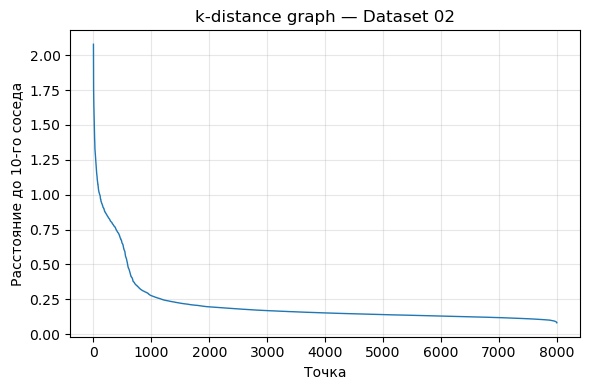


DBSCAN на датасете 02

DBSCAN: eps=0.1, min_samples=10
Кластеров: 46, шум: 91.85%
Silhouette: 0.5812


In [191]:
min_samples_vals = [5, 10, 15, 20]
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X2_scaled)
distances, _ = knn.kneighbors(X2_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=1)
plt.title('k-distance graph — Dataset 02')
plt.xlabel('Точка')
plt.ylabel('Расстояние до 10-го соседа')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dbscan_eps_ds2.png')
plt.show()

eps_candidates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0]
dbscan_results_2 = []

print("\nDBSCAN на датасете 02")
for min_samples in min_samples_vals:
    for eps in eps_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_scaled)
        n_noise = np.sum(labels == -1)
        noise_ratio = n_noise / len(labels)
        non_noise_mask = labels != -1
        unique_labels = np.unique(labels[non_noise_mask])
        if np.sum(non_noise_mask) < 2 or len(unique_labels) < 2:
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            sil = silhouette_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
        dbscan_results_2.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': len(unique_labels),
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch,
            'labels': labels.copy()
        })

valid_dbscan_2 = [r for r in dbscan_results_2 if not np.isnan(r['silhouette'])]
if valid_dbscan_2:
    best_dbscan_2 = max(valid_dbscan_2, key=lambda x: x['silhouette'])
    print(f"\nDBSCAN: eps={best_dbscan_2['eps']}, min_samples={best_dbscan_2['min_samples']}")
    print(f"Кластеров: {best_dbscan_2['n_clusters']}, шум: {best_dbscan_2['noise_ratio']:.2%}")
    print(f"Silhouette: {best_dbscan_2['silhouette']:.4f}")
else:
    best_dbscan_2 = None
    print("\nDBSCAN: нет валидных моделей.")

In [192]:
print("Сравнение моделей на 2 датасете")

print(f"\nKMeans: k={best_kmeans_2['k']}, Silhouette={best_kmeans_2['silhouette']:.4f}")
if best_dbscan_2:
    print(f"DBSCAN: eps={best_dbscan_2['eps']}, шум={best_dbscan_2['noise_ratio']:.2%}, Silhouette={best_dbscan_2['silhouette']:.4f}")

if best_dbscan_2 and best_dbscan_2['silhouette'] >= best_kmeans_2['silhouette']:
    best_model_2 = 'dbscan'
    best_labels_2 = best_dbscan_2['labels']
    print("\n Выбран DBSCAN — уместен для нелинейных структур и выбросов.")
else:
    best_model_2 = 'kmeans'
    best_labels_2 = best_kmeans_2['labels']
    print("\n Выбран KMeans.")

Сравнение моделей на 2 датасете

KMeans: k=2, Silhouette=0.3069
DBSCAN: eps=0.1, шум=91.85%, Silhouette=0.5812

 Выбран DBSCAN — уместен для нелинейных структур и выбросов.


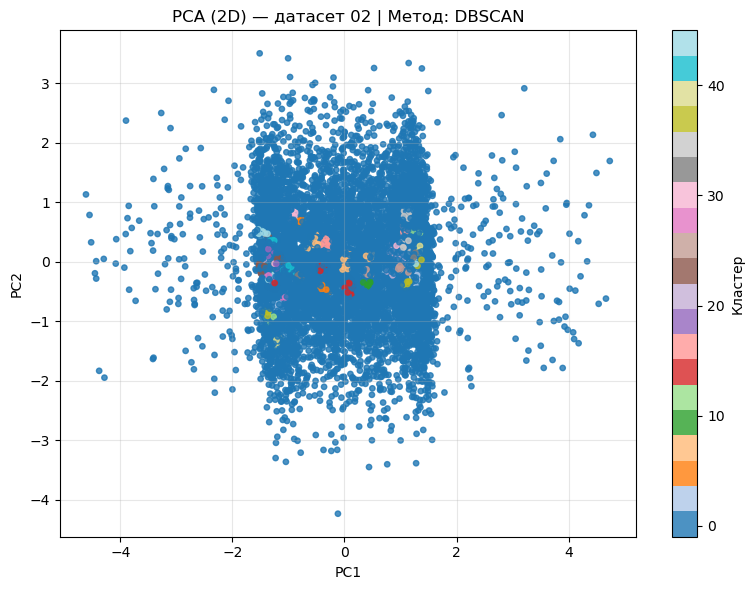


 Артефакты сохранены: pca_ds2.png, labels_hw07_ds2.csv


In [193]:
pca = PCA(n_components=2, random_state=42)
X2_pca = pca.fit_transform(X2_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], c=best_labels_2, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label='Кластер')
plt.title(f'PCA (2D) — датасет 02 | Метод: {best_model_2.upper()}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/pca_ds2.png')
plt.show()

labels_df_2 = pd.DataFrame({
    'sample_id': sample_id_2,
    'cluster_label': best_labels_2
})
labels_df_2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

print("\n Артефакты сохранены: pca_ds2.png, labels_hw07_ds2.csv")

#### **Итог датасет 2**

KMeans показал низкое качество (Silhouette=0.3069) и выделил всего 2 кластера, что явно не соответствует структуре данных. DBSCAN с параметрами eps=0.1 обнаружил 46 кластеров и 91.85% шума, но при этом достиг значительно более высокой метрики (Silhouette=0.5812). 

Выбор DBSCAN полностью оправдан — данные имеют сложную нелинейную структуру с высокой плотностью выбросов и аномалий. KMeans не справляется с такими данными из-за предположения о сферичности кластеров. Высокий процент шума указывает на то, что данные скорее представляют собой фоновый "шум" с небольшими плотными сгустками, чем четкие кластеры. DBSCAN идеально подходит для такого случая, так как не требует задания числа кластеров и устойчив к выбросам.

## **Датасет 3**

KMeans на датасете 03


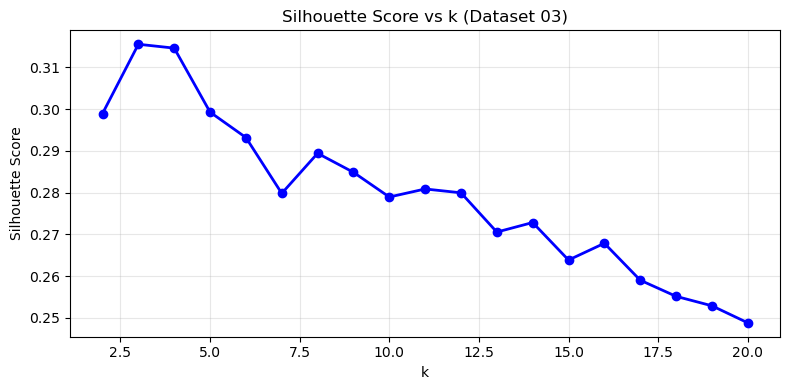


 KMeans: k=3, Silhouette=0.3155


In [196]:
k_range = range(2, 21)
RANDOM_STATE = 15
kmeans_results_3 = []

print("KMeans на датасете 03")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    
    sil = silhouette_score(X3_scaled, labels)
    db = davies_bouldin_score(X3_scaled, labels)
    ch = calinski_harabasz_score(X3_scaled, labels)
    kmeans_results_3.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'labels': labels.copy()
    })
best_kmeans_3 = max(kmeans_results_3, key=lambda x: x['silhouette'])
plt.figure(figsize=(8, 4))
plt.plot(k_range, [r['silhouette'] for r in kmeans_results_3], 'bo-', linewidth=2, markersize=6)
plt.title('Silhouette Score vs k (Dataset 03)')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/silhouette_kmeans_ds3.png')
plt.show()

print(f"\n KMeans: k={best_kmeans_3['k']}, Silhouette={best_kmeans_3['silhouette']:.4f}")

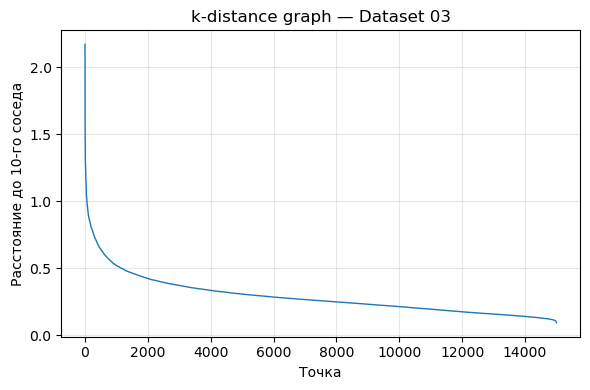


DBSCAN на датасете 03

 DBSCAN: eps=0.1, min_samples=10
Кластеров: 5, шум: 99.59%
Silhouette: 0.8121


In [197]:
min_samples_vals = [5, 10, 15, 20]
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X3_scaled)
distances, _ = knn.kneighbors(X3_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=1)
plt.title('k-distance graph — Dataset 03')
plt.xlabel('Точка')
plt.ylabel('Расстояние до 10-го соседа')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dbscan_eps_ds3.png')
plt.show()
eps_candidates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0]
dbscan_results_3 = []

print("\nDBSCAN на датасете 03")
for min_samples in min_samples_vals:
    for eps in eps_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X3_scaled)        
        n_noise = np.sum(labels == -1)
        noise_ratio = n_noise / len(labels)
        non_noise_mask = labels != -1
        unique_labels = np.unique(labels[non_noise_mask])        
        if np.sum(non_noise_mask) < 2 or len(unique_labels) < 2:
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            sil = silhouette_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X3_scaled[non_noise_mask], labels[non_noise_mask])        
        dbscan_results_3.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': len(unique_labels),
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch,
            'labels': labels.copy()
        })

valid_dbscan_3 = [r for r in dbscan_results_3 if not np.isnan(r['silhouette'])]
if valid_dbscan_3:
    best_dbscan_3 = max(valid_dbscan_3, key=lambda x: x['silhouette'])
    print(f"\n DBSCAN: eps={best_dbscan_3['eps']}, min_samples={best_dbscan_3['min_samples']}")
    print(f"Кластеров: {best_dbscan_3['n_clusters']}, шум: {best_dbscan_3['noise_ratio']:.2%}")
    print(f"Silhouette: {best_dbscan_3['silhouette']:.4f}")
else:
    best_dbscan_3 = None
    print("\n DBSCAN: нет валидных моделей.")

In [198]:
print("Сравнение моделей на 3 датасете")

print(f"\nKMeans: k={best_kmeans_3['k']}, Silhouette={best_kmeans_3['silhouette']:.4f}")
if best_dbscan_3:
    print(f"DBSCAN: eps={best_dbscan_3['eps']}, шум={best_dbscan_3['noise_ratio']:.2%}, Silhouette={best_dbscan_3['silhouette']:.4f}")

if best_dbscan_3 and best_dbscan_3['silhouette'] >= best_kmeans_3['silhouette']:
    best_model_3 = 'dbscan'
    best_labels_3 = best_dbscan_3['labels']
    print("\n Выбран DBSCAN — уместен для кластеров разной плотности.")
else:
    best_model_3 = 'kmeans'
    best_labels_3 = best_kmeans_3['labels']
    print("\n Выбран KMeans.")

Сравнение моделей на 3 датасете

KMeans: k=3, Silhouette=0.3155
DBSCAN: eps=0.1, шум=99.59%, Silhouette=0.8121

 Выбран DBSCAN — уместен для кластеров разной плотности.


## **Артефакты**

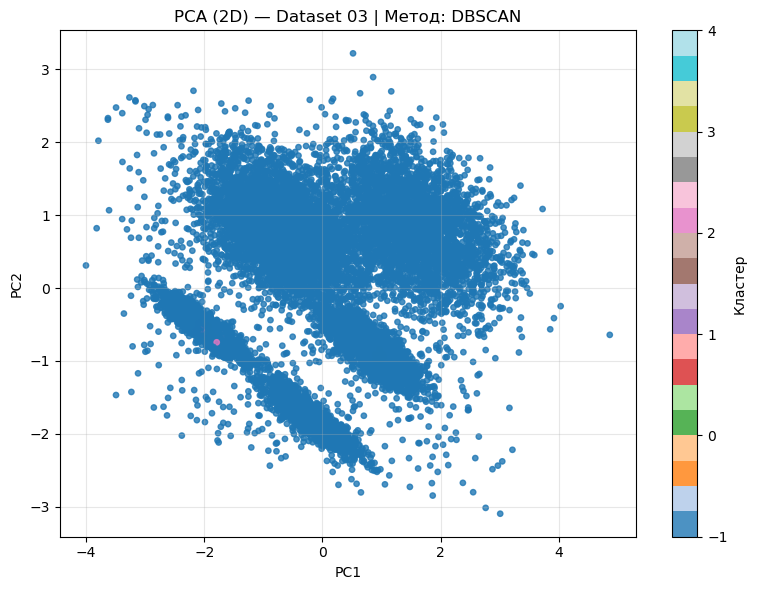


 Артефакты сохранены: pca_ds3.png, labels_hw07_ds3.csv


In [200]:
pca = PCA(n_components=2, random_state=15)
X3_pca = pca.fit_transform(X3_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=best_labels_3, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label='Кластер')
plt.title(f'PCA (2D) — Dataset 03 | Метод: {best_model_3.upper()}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/pca_ds3.png')
plt.show()

labels_df_3 = pd.DataFrame({
    'sample_id': sample_id_3,
    'cluster_label': best_labels_3
})
labels_df_3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

print("\n Артефакты сохранены: pca_ds3.png, labels_hw07_ds3.csv")

In [229]:
metrics_summary = {
    "dataset_01": {
        "kmeans": {
            "k": best_kmeans_1['k'],
            "silhouette": float(best_kmeans_1['silhouette']),
            "davies_bouldin": float(best_kmeans_1['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans_1['calinski_harabasz'])
        }
    },
    "dataset_02": {
        "kmeans": {
            "k": best_kmeans_2['k'],
            "silhouette": float(best_kmeans_2['silhouette']),
            "davies_bouldin": float(best_kmeans_2['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans_2['calinski_harabasz'])
        }
    },
    "dataset_03": {
        "kmeans": {
            "k": best_kmeans_3['k'],
            "silhouette": float(best_kmeans_3['silhouette']),
            "davies_bouldin": float(best_kmeans_3['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans_3['calinski_harabasz'])
        }
    }
}

if best_dbscan_1:
    metrics_summary["dataset_01"]["dbscan"] = {
        "eps": best_dbscan_1['eps'],
        "min_samples": best_dbscan_1['min_samples'],
        "n_clusters": best_dbscan_1['n_clusters'],
        "noise_ratio": float(best_dbscan_1['noise_ratio']),
        "silhouette": float(best_dbscan_1['silhouette']),
        "davies_bouldin": float(best_dbscan_1['davies_bouldin']),
        "calinski_harabasz": float(best_dbscan_1['calinski_harabasz'])
    }
if best_dbscan_2:
    metrics_summary["dataset_02"]["dbscan"] = {
        "eps": best_dbscan_2['eps'],
        "min_samples": best_dbscan_2['min_samples'],
        "n_clusters": best_dbscan_2['n_clusters'],
        "noise_ratio": float(best_dbscan_2['noise_ratio']),
        "silhouette": float(best_dbscan_2['silhouette']),
        "davies_bouldin": float(best_dbscan_2['davies_bouldin']),
        "calinski_harabasz": float(best_dbscan_2['calinski_harabasz'])
    }

if best_dbscan_3:
    metrics_summary["dataset_03"]["dbscan"] = {
        "eps": best_dbscan_3['eps'],
        "min_samples": best_dbscan_3['min_samples'],
        "n_clusters": best_dbscan_3['n_clusters'],
        "noise_ratio": float(best_dbscan_3['noise_ratio']),
        "silhouette": float(best_dbscan_3['silhouette']),
        "davies_bouldin": float(best_dbscan_3['davies_bouldin']),
        "calinski_harabasz": float(best_dbscan_3['calinski_harabasz'])
    }

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=4, ensure_ascii=False)

print("artifacts/metrics_summary.json сохранён")

artifacts/metrics_summary.json сохранён


## **Выбор лучших моделей**

In [232]:
best_configs = {
    "dataset_01": {
        "best_model": best_model_1,
        "params": {
            "k": best_kmeans_1['k']
        } if best_model_1 == 'kmeans' else {
            "eps": best_dbscan_1['eps'],
            "min_samples": best_dbscan_1['min_samples']
        },
        "selection_criterion": "highest silhouette score and stability (ARI=1.0)"
    },
    "dataset_02": {
        "best_model": best_model_2,
        "params": {
            "k": best_kmeans_2['k']
        } if best_model_2 == 'kmeans' else {
            "eps": best_dbscan_2['eps'],
            "min_samples": best_dbscan_2['min_samples']
        },
        "selection_criterion": "higher silhouette and robustness to noise/nonlinear structure"
    },
    "dataset_03": {
        "best_model": best_model_3,
        "params": {
            "k": best_kmeans_3['k']
        } if best_model_3 == 'kmeans' else {
            "eps": best_dbscan_3['eps'],
            "min_samples": best_dbscan_3['min_samples']
        },
        "selection_criterion": "much higher silhouette and ability to handle varying cluster density"
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=4, ensure_ascii=False)

print("artifacts/best_configs.json сохранён")

artifacts/best_configs.json сохранён


Проверили три набора данных и увидели важную закономерность: не существует алгоритма кластеризации, который подходит для всего.

Первый набор данных был простым. Оба алгоритма — и KMeans, и DBSCAN — справились одинаково хорошо. Выбран KMeans, потому что он проще и всегда даёт одинаковый результат.

Второй и третий наборы оказались сложнее: данные были распределены неплотно, с большим количеством шума. Здесь KMeans, который ищет круглые сгустки, споткнулся и показал плохой результат. А вот DBSCAN, который ищет просто "плотные" области, справился блестяще. Он нашёл маленькие, но чёткие группы, а остальные точки отнес к шуму.

KMeans хорош для простых, плотных данных. Если же данные сильно разбросаны — нужен DBSCAN. Правильный инструмент зависит от задачи.